In [57]:
# Imprting the Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [59]:
# CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [60]:
# Image Classification
import cv2

In [61]:
import os

In [62]:
# Supressing warnings
import warnings
warnings.filterwarnings("ignore")

In [63]:
# Dataset
mask_data = "data"
mask_data

'data'

In [64]:
# Data Augmentation
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    horizontal_flip = True,
    rotation_range=10
)
datagen

In [65]:
# Get Images from directors
train_generator = datagen.flow_from_directory(
    mask_data,
    target_size = (64, 64),
    batch_size = 64,
    class_mode = 'binary',
    subset = 'training',
    shuffle = True,
    seed = 42
)
train_generator

Found 6043 images belonging to 2 classes.


In [66]:
val_generator = datagen.flow_from_directory(
    mask_data,
    target_size = (64, 64),
    batch_size = 64,
    class_mode = 'binary',
    subset= 'validation',
    shuffle = False,
    seed = 42
)
val_generator

Found 1510 images belonging to 2 classes.


In [67]:
print(train_generator.class_indices)
print(val_generator.class_indices)

{'with_mask': 0, 'without_mask': 1}
{'with_mask': 0, 'without_mask': 1}


In [68]:
# Training Dataset
print("Image Size of Train Dataset:",train_generator.image_shape)
print("Batch Size of Train Dataset:",train_generator.batch_size)
print("Number of Images in Train Dataset:",train_generator.samples)
print("Classes in Train Dataset:",train_generator.class_indices)
print("Number of Classes in Train Dataset:",train_generator.num_classes)

Image Size of Train Dataset: (64, 64, 3)
Batch Size of Train Dataset: 64
Number of Images in Train Dataset: 6043
Classes in Train Dataset: {'with_mask': 0, 'without_mask': 1}
Number of Classes in Train Dataset: 2


In [69]:
# Testing Dataset
print("Image Size of Validation Dataset:",val_generator.image_shape)
print("Batch Size of Validation Dataset:",val_generator.batch_size)
print("Number of Images in Validation Dataset:",val_generator.samples)
print("Classes in Validation Dataset:",val_generator.class_indices)
print("Number of Classes in Validation Dataset:",val_generator.num_classes)

Image Size of Validation Dataset: (64, 64, 3)
Batch Size of Validation Dataset: 64
Number of Images in Validation Dataset: 1510
Classes in Validation Dataset: {'with_mask': 0, 'without_mask': 1}
Number of Classes in Validation Dataset: 2


In [70]:
class_counts_train = np.bincount(train_generator.classes)
class_counts_train

array([2980, 3063], dtype=int64)

In [71]:
class_names_train = list(train_generator.class_indices.keys())
class_names_train

['with_mask', 'without_mask']

In [72]:
colors = ['green' if cls == 'with_mask' else 'red' for cls in class_names_train]
colors

['green', 'red']

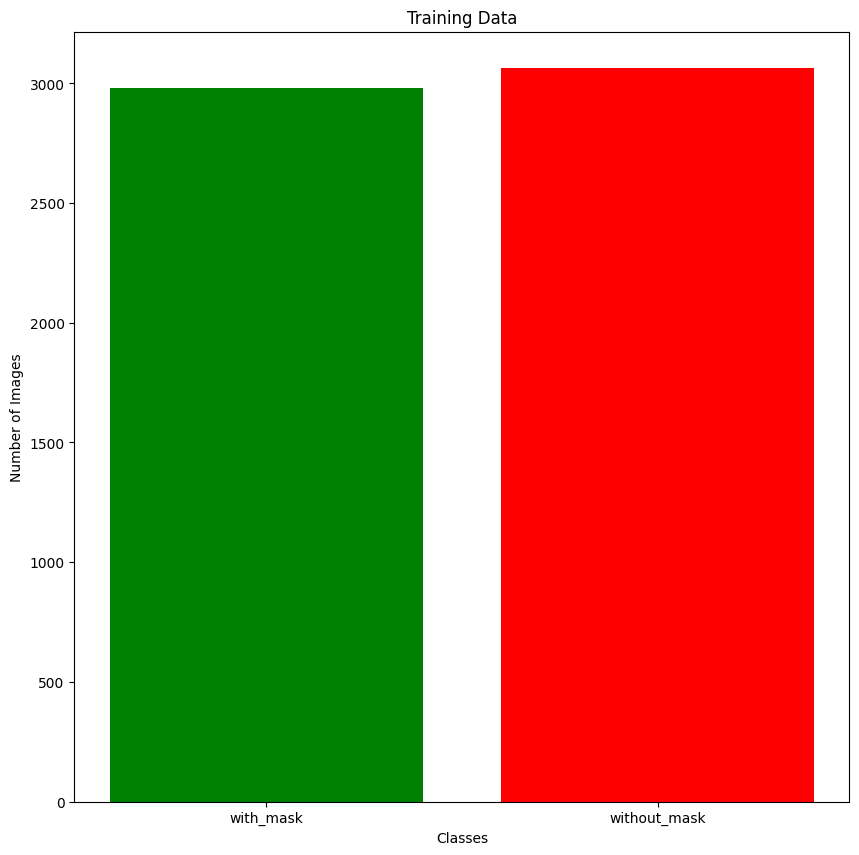

In [73]:
plt.figure(figsize=(10, 10))
plt.bar(
    x=class_names_train,
    height=class_counts_train,
    color=colors
)
plt.title("Training Data")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [74]:
class_counts_test = np.bincount(val_generator.classes)
class_counts_test

array([745, 765], dtype=int64)

In [75]:
class_names_test = list(val_generator.class_indices.keys())
class_names_test

['with_mask', 'without_mask']

In [76]:
colors = ['green' if cls == 'with_mask' else 'red' for cls in class_names_test]
colors

['green', 'red']

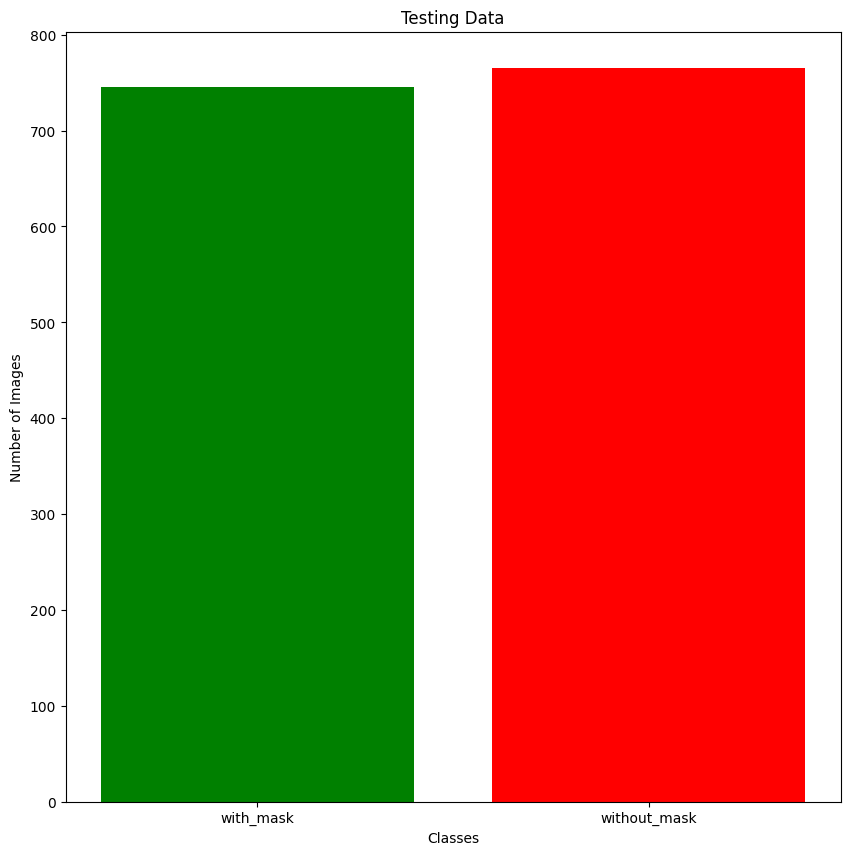

In [77]:
plt.figure(figsize=(10, 10))
plt.bar(
    x=class_names_test,
    height=class_counts_test,
    color=colors
)
plt.title("Testing Data")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [78]:
train_df = pd.DataFrame(
    {
        "filename": train_generator.filenames,
        "class": train_generator.classes
    }
)
train_df

,filename,class
0,with_mask\with_mask_167.jpg,0
1,with_mask\with_mask_1670.jpg,0
2,with_mask\with_mask_1671.jpg,0
3,with_mask\with_mask_1672.jpg,0
4,with_mask\with_mask_1673.jpg,0
...,...,...
6038,without_mask\without_mask_995.jpg,1
6039,without_mask\without_mask_996.jpg,1
6040,without_mask\without_mask_997.jpg,1
6041,without_mask\without_mask_998.jpg,1


In [79]:
val_df = pd.DataFrame(
    {
        "filename": val_generator.filenames,
        "class": val_generator.classes
    }
)
val_df

,filename,class
0,with_mask\with_mask_1.jpg,0
1,with_mask\with_mask_10.jpg,0
2,with_mask\with_mask_100.jpg,0
3,with_mask\with_mask_1000.jpg,0
4,with_mask\with_mask_1001.jpg,0
...,...,...
1505,without_mask\without_mask_1683.jpg,1
1506,without_mask\without_mask_1684.jpg,1
1507,without_mask\without_mask_1685.jpg,1
1508,without_mask\without_mask_1686.jpg,1


In [80]:
model = Sequential()

# Input Layer
model.add(Input(shape=(64, 64, 3)))

# Conv Block 1
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Conv Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Conv Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Conv Block 4
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

# Global Pooling before Dense
model.add(GlobalAveragePooling2D())

# Dense Layers (to reach 10 hidden layers)
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [81]:
model

<Sequential name=sequential_1, built=True>

In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 490,689 (1.87 MB)

 Trainable params: 488,961 (1.87 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [83]:
# Compiling the model
model.compile(Adam(learning_rate=0.00005), 
              loss='binary_crossentropy', 
              metrics=['accuracy']
)

In [84]:
# Fitting
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch = len(train_generator) // 8,
    validation_steps = len(val_generator) // 8
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 160s 9s/step - accuracy: 0.4858 - loss: 1.0885 - val_accuracy: 1.0000 - val_loss: 0.6555
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.6277 - loss: 0.7190 - val_accuracy: 1.0000 - val_loss: 0.6384
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.6670 - loss: 0.6966 - val_accuracy: 1.0000 - val_loss: 0.6269
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.6785 - loss: 0.6610 - val_accuracy: 1.0000 - val_loss: 0.6141
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.7529 - loss: 0.5356 - val_accuracy: 1.0000 - val_loss: 0.5930
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.7570 - loss: 0.5264 - val_accuracy: 1.0000 - val_loss: 0.5685
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.7196 - loss: 0.5788 - val_accuracy: 1.0000 - val_loss: 0.5573
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.7405 - loss: 0.5268 - val_accuracy: 1.0000 - 

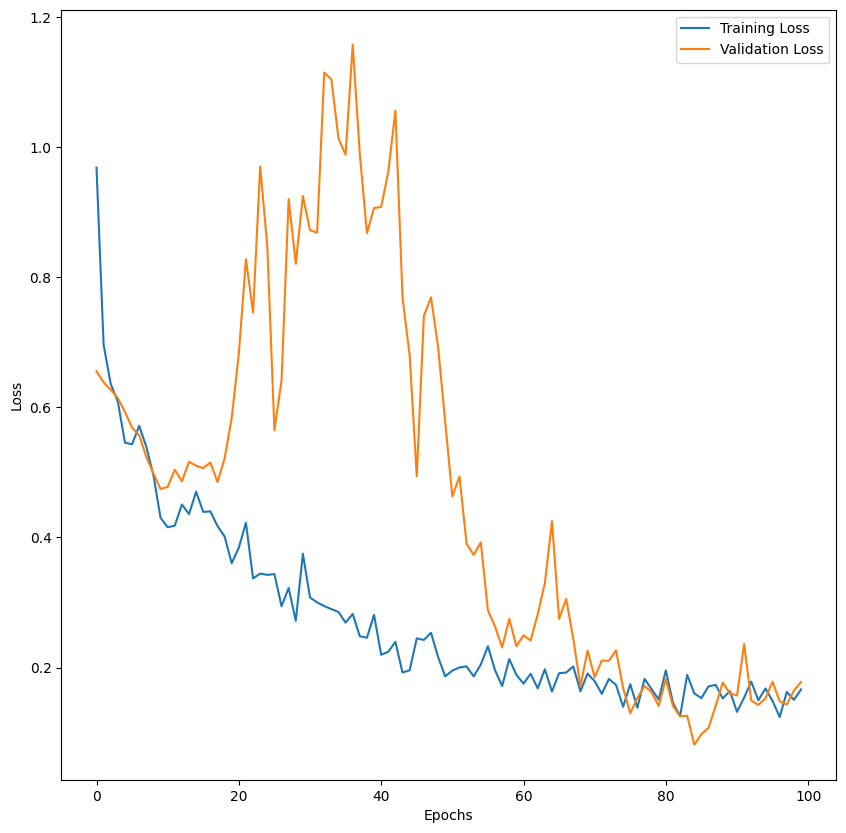

In [85]:
# Line Plot for Loss
plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

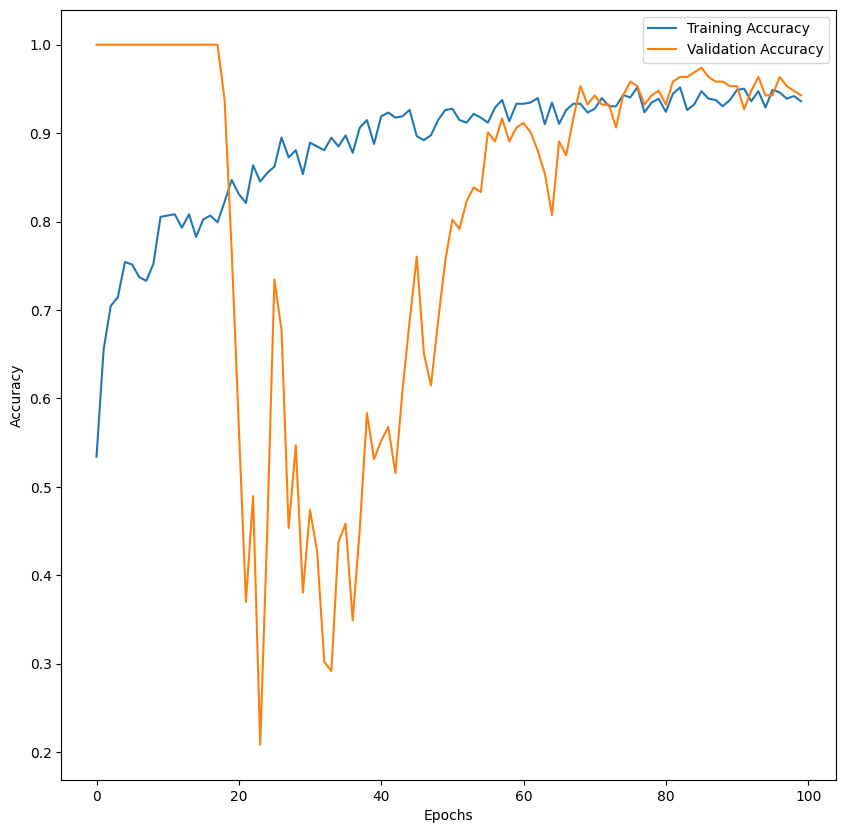

In [86]:
# Line Plot for Accuracy
plt.figure(figsize=(10, 10))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [87]:
# Model Evaluation
train_loss, train_acc = model.evaluate(train_generator)
test_loss, test_acc = model.evaluate(val_generator)

# Loss (upto 2 Decimal places)
print("Training Loss:", round(train_loss, 2))
print("Testing Loss:", round(test_loss, 2))

# Accuracy (in % upto 2 decimal places)
print("Training Accuracy:", round(train_acc * 100, 2), "%")
print("Testing Accuracy:", round(test_acc * 100, 2), "%")

95/95 ━━━━━━━━━━━━━━━━━━━━ 72s 611ms/step - accuracy: 0.9627 - loss: 0.1023
24/24 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.9620 - loss: 0.1247
Training Loss: 0.11
Testing Loss: 0.12
Training Accuracy: 96.13 %
Testing Accuracy: 95.7 %


In [88]:
# Model Predict (upto 2 Decimal Places)
y_pred = model.predict(val_generator)
y_pred = np.round(y_pred, 2)
y_pred

24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 518ms/step


array([[0.  ],
       [0.55],
       [0.06],
       ...,
       [0.54],
       [1.  ],
       [1.  ]], dtype=float32)

In [89]:
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_pred_classes

array([0, 1, 0, ..., 1, 1, 1])

In [90]:
print("Predicted:", np.unique(y_pred_classes))

Predicted: [0 1]


In [91]:
y_true = val_generator.classes
y_true

array([0, 0, 0, ..., 1, 1, 1])

In [92]:
# Classification Report
cr = classification_report(y_true, y_pred_classes, target_names = list(val_generator.class_indices.keys()))
print(cr)

              precision    recall  f1-score   support

   with_mask       0.95      0.97      0.96       745
without_mask       0.97      0.95      0.96       765

    accuracy                           0.96      1510
   macro avg       0.96      0.96      0.96      1510
weighted avg       0.96      0.96      0.96      1510



In [93]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[721  24]
 [ 36 729]]


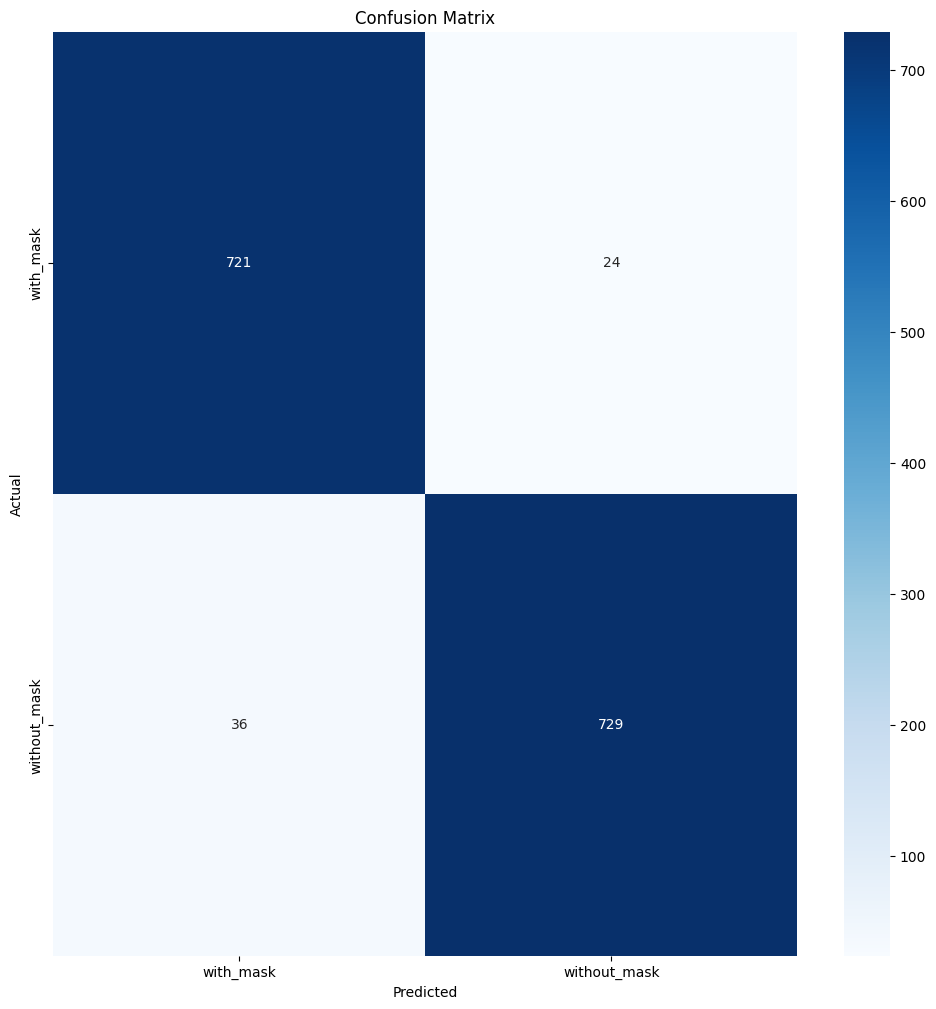

In [94]:
plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=list(val_generator.class_indices.keys()), 
            yticklabels=list(val_generator.class_indices.keys())
           )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [95]:
# Accuracy Score (in %)
accuracy = accuracy_score(y_true, y_pred_classes) * 100
print("Accuracy:", round(accuracy, 2), "%")

Accuracy: 96.03 %


In [96]:
# Save the Models
model.save("models/model.h5")

In [97]:
# Prediction Engine
def predict_mask(img_path):

    class_names = ["Mask", "No Mask"]

    # Load image
    img = image.load_img(img_path, target_size=(64,64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = class_names[1]
        confidence = prediction * 100
    else:
        label = class_names[0]
        confidence = (1 - prediction) * 100

    # Display
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({confidence:.2f}%)")
    plt.show()

    return label, confidence

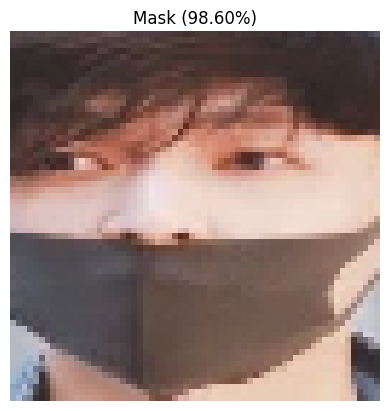

('Mask', 98.59918421134353)

In [98]:
predict_mask('data\with_mask\with_mask_1001.jpg')

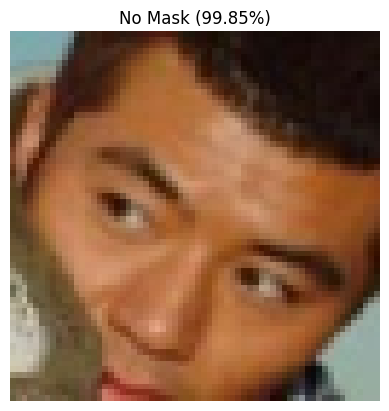

('No Mask', 99.84633326530457)

In [99]:
predict_mask('data\without_mask\without_mask_1001.jpg')